# Практическая 15 (Саттаров Булат Рамилевич ЭФМО-01-25)

## Задание

1. **Классификация.** Сформировать датасет командой `make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=2)`. Подобрать тип ядра и гиперпараметры SVM. Выполнить визуальное сравнение разных ядер и гиперпараметров. Сравнить точность.
2. **Регрессия.** Использовать датасет по гиперспектру кукурузы. Подобрать тип ядра и гиперпараметры SVR. Выполнить визуальное сравнение разных ядер и гиперпараметров. Сравнить точность.
3. Использовать любой из датасетов и два метода классификации или регрессии, изученные ранее. Сравнить эти методы с SVM не только по точности, но и по другим метрикам качества.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [2]:
SEED = 42
np.random.seed(SEED)

## Вспомогательные функции

In [3]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(True)

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

# 1. SVM для классификации

Сформируем синтетический датасет из условия. В нем 100 объектов, 2 признака и 2 класса. Так как признака всего два, границы решений удобно визуализировать.

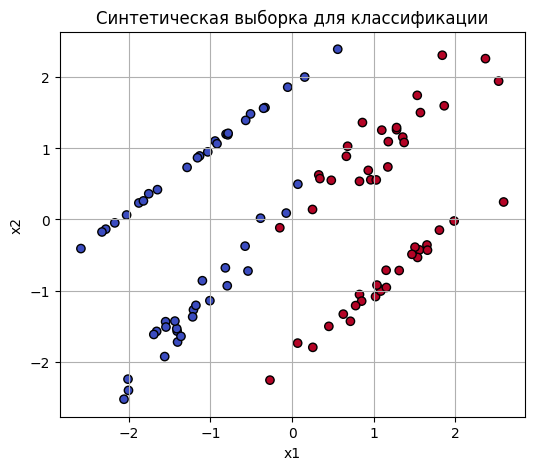

In [4]:
X, Y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    random_state=SEED
)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=SEED,
    stratify=Y
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', edgecolor='k')
plt.title('Синтетическая выборка для классификации')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

## Сравнение разных ядер SVM

Проверим линейное, полиномиальное, RBF и sigmoid-ядро. Для честного сравнения признаки масштабируются через `StandardScaler`.

In [5]:
svc_variants = [
    ('linear C=1', SVC(kernel='linear', C=1, probability=True, random_state=SEED)),
    ('poly C=1 degree=3', SVC(kernel='poly', C=1, degree=3, probability=True, random_state=SEED)),
    ('rbf C=1 gamma=scale', SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=SEED)),
    ('rbf C=10 gamma=1', SVC(kernel='rbf', C=10, gamma=1, probability=True, random_state=SEED)),
    ('sigmoid C=1', SVC(kernel='sigmoid', C=1, probability=True, random_state=SEED)),
]

svc_results = []
fitted_svc = {}

for name, model in svc_variants:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    svc_results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC AUC': roc_auc_score(y_test, proba)
    })
    fitted_svc[name] = pipe

svc_results_df = pd.DataFrame(svc_results).sort_values('F1', ascending=False)
svc_results_df

,Модель,Accuracy,Precision,Recall,F1,ROC AUC
0,linear C=1,1.000000,1.0000,1.000000,1.000000,1.0
2,rbf C=1 gamma=scale,1.000000,1.0000,1.000000,1.000000,1.0
4,sigmoid C=1,1.000000,1.0000,1.000000,1.000000,1.0
1,poly C=1 degree=3,0.966667,0.9375,1.000000,0.967742,1.0
3,rbf C=10 gamma=1,0.966667,1.0000,0.933333,0.965517,1.0


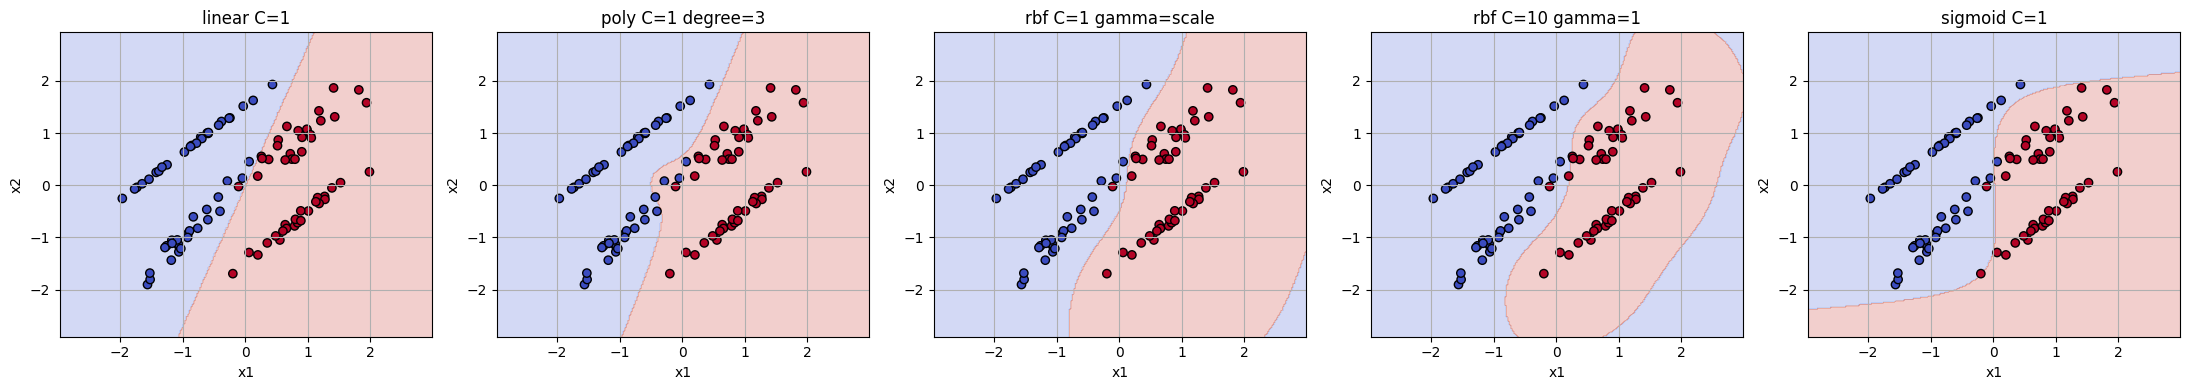

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pipe) in zip(axes, fitted_svc.items()):
    # Для визуализации границ решений используем масштабированные данные и модель после scaler.
    X_scaled = pipe.named_steps['scaler'].transform(X)
    plot_decision_boundary(pipe.named_steps['svc'], X_scaled, Y, ax, name)
plt.tight_layout()
plt.show()

## Подбор гиперпараметров SVM

Подберем `kernel`, `C`, `gamma` и `degree` через `GridSearchCV`. Основной метрикой возьмем `f1`, так как она учитывает и точность, и полноту.

In [7]:
svc_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, random_state=SEED))
])

param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 10, 100]},
    {'svc__kernel': ['rbf'], 'svc__C': [0.1, 1, 10, 100], 'svc__gamma': ['scale', 0.1, 1, 10]},
    {'svc__kernel': ['poly'], 'svc__C': [0.1, 1, 10], 'svc__degree': [2, 3, 4], 'svc__gamma': ['scale', 0.1, 1]},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_svc = GridSearchCV(svc_grid, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_svc.fit(X_train, y_train)

print('Лучшие параметры:', grid_svc.best_params_)
print('Лучший CV F1:', round(grid_svc.best_score_, 4))

Лучшие параметры: {'svc__C': 1, 'svc__kernel': 'linear'}
Лучший CV F1: 0.9846


In [8]:
best_svc = grid_svc.best_estimator_
best_pred = best_svc.predict(X_test)
best_proba = best_svc.predict_proba(X_test)[:, 1]

print('Accuracy:', round(accuracy_score(y_test, best_pred), 4))
print('Precision:', round(precision_score(y_test, best_pred), 4))
print('Recall:', round(recall_score(y_test, best_pred), 4))
print('F1:', round(f1_score(y_test, best_pred), 4))
print('ROC AUC:', round(roc_auc_score(y_test, best_proba), 4))
print()
print(classification_report(y_test, best_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC AUC: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



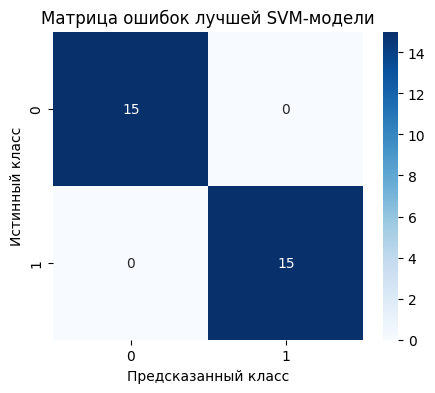

In [9]:
matrix = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок лучшей SVM-модели')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# 2. SVR для регрессии на гиперспектре кукурузы

Загрузим датасет по гиперспектру кукурузы. Признак `wavelength` — длина волны, `Spectr` — значение спектра. Будем предсказывать `Spectr` по длине волны.

In [10]:
corn = pd.read_csv('Гиперспектр кукурузы.csv', sep=';')
for col in corn.columns:
    corn[col] = corn[col].astype(str).str.replace(',', '.', regex=False).astype(float)

corn.head()

,wavelength,Spectr
0,397.32,0.02
1,399.54,0.03
2,401.76,0.03
3,403.98,0.05
4,406.20,0.05


(273, 2)
        wavelength      Spectr
count   273.000000  273.000000
mean    699.240000    0.283773
std     175.274589    0.177381
min     397.320000    0.020000
25%     548.280000    0.160000
50%     699.240000    0.190000
75%     850.200000    0.450000
max    1001.160000    0.620000


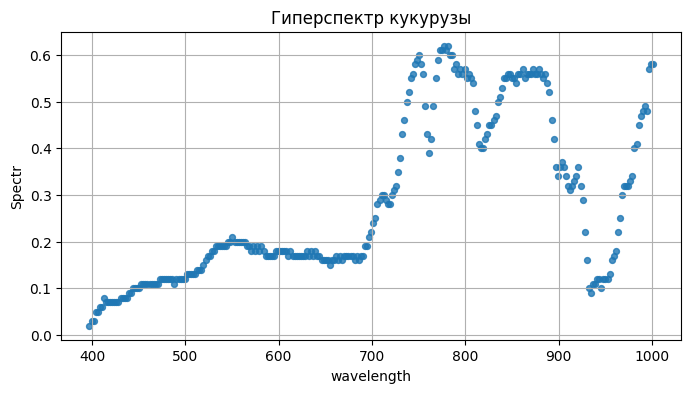

In [11]:
print(corn.shape)
print(corn.describe())

plt.figure(figsize=(8, 4))
plt.scatter(corn['wavelength'], corn['Spectr'], s=18, alpha=0.8)
plt.title('Гиперспектр кукурузы')
plt.xlabel('wavelength')
plt.ylabel('Spectr')
plt.grid(True)
plt.show()

In [12]:
X_reg = corn[['wavelength']].values
y_reg = corn['Spectr'].values

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.25,
    random_state=SEED
)

## Сравнение разных ядер SVR

In [13]:
svr_variants = [
    ('linear C=1', SVR(kernel='linear', C=1)),
    ('poly C=10 degree=3', SVR(kernel='poly', C=10, degree=3, epsilon=0.01)),
    ('rbf C=10 gamma=scale', SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.01)),
    ('rbf C=100 gamma=0.1', SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.01)),
]

svr_results = []
fitted_svr = {}

for name, model in svr_variants:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', model)
    ])
    pipe.fit(X_train_reg, y_train_reg)
    pred = pipe.predict(X_test_reg)
    svr_results.append({'Модель': name, **regression_metrics(y_test_reg, pred)})
    fitted_svr[name] = pipe

svr_results_df = pd.DataFrame(svr_results).sort_values('RMSE')
svr_results_df

,Модель,MAE,RMSE,R2
2,rbf C=10 gamma=scale,0.032161,0.049471,0.916951
3,rbf C=100 gamma=0.1,0.071796,0.106374,0.616025
0,linear C=1,0.105791,0.132381,0.405316
1,poly C=10 degree=3,0.107844,0.157135,0.162129


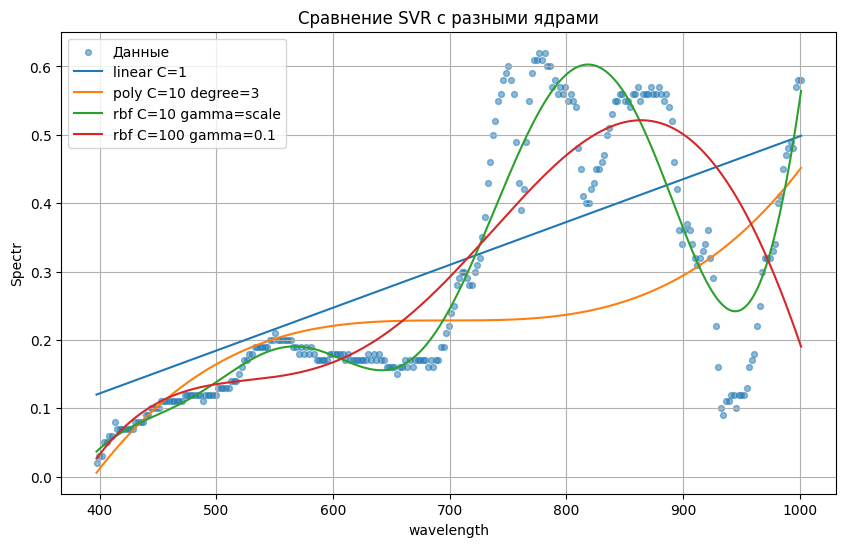

In [14]:
x_grid = np.linspace(X_reg.min(), X_reg.max(), 500).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, s=18, alpha=0.5, label='Данные')
for name, pipe in fitted_svr.items():
    plt.plot(x_grid, pipe.predict(x_grid), label=name)
plt.title('Сравнение SVR с разными ядрами')
plt.xlabel('wavelength')
plt.ylabel('Spectr')
plt.legend()
plt.grid(True)
plt.show()

## Подбор гиперпараметров SVR

In [15]:
svr_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

svr_param_grid = [
    {'svr__kernel': ['linear'], 'svr__C': [0.1, 1, 10, 100], 'svr__epsilon': [0.001, 0.01, 0.05]},
    {'svr__kernel': ['rbf'], 'svr__C': [1, 10, 100, 500], 'svr__gamma': ['scale', 0.01, 0.1, 1], 'svr__epsilon': [0.001, 0.01, 0.05]},
    {'svr__kernel': ['poly'], 'svr__C': [1, 10, 100], 'svr__degree': [2, 3, 4], 'svr__epsilon': [0.001, 0.01, 0.05]},
]

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
grid_svr = GridSearchCV(svr_grid, svr_param_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_svr.fit(X_train_reg, y_train_reg)

print('Лучшие параметры:', grid_svr.best_params_)
print('Лучший CV RMSE:', round(-grid_svr.best_score_, 4))

Лучшие параметры: {'svr__C': 500, 'svr__epsilon': 0.001, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
Лучший CV RMSE: 0.0546


In [16]:
best_svr = grid_svr.best_estimator_
best_svr_pred = best_svr.predict(X_test_reg)
best_svr_metrics = regression_metrics(y_test_reg, best_svr_pred)

for key, value in best_svr_metrics.items():
    print(key, round(value, 4))

MAE 0.0271
RMSE 0.0385
R2 0.9496


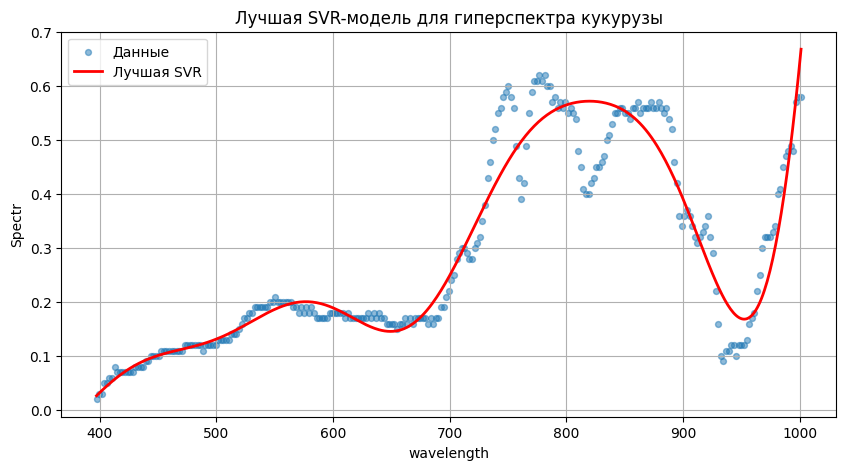

In [17]:
plt.figure(figsize=(10, 5))
plt.scatter(X_reg, y_reg, s=18, alpha=0.5, label='Данные')
plt.plot(x_grid, best_svr.predict(x_grid), color='red', linewidth=2, label='Лучшая SVR')
plt.title('Лучшая SVR-модель для гиперспектра кукурузы')
plt.xlabel('wavelength')
plt.ylabel('Spectr')
plt.legend()
plt.grid(True)
plt.show()

# 3. Сравнение SVM с методами из прошлых занятий

Для сравнения возьмем синтетический датасет классификации из первой части. Сравним SVM с kNN, деревом решений и случайным лесом.

In [18]:
comparison_models = {
    'SVM tuned': best_svc,
    'kNN': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))]),
    'DecisionTree': DecisionTreeClassifier(max_depth=4, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
}

comparison_rows = []
for name, model in comparison_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        proba = pred
    comparison_rows.append({
        'Метод': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC AUC': roc_auc_score(y_test, proba)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('F1', ascending=False)
comparison_df

,Метод,Accuracy,Precision,Recall,F1,ROC AUC
0,SVM tuned,1.0,1.0,1.0,1.000000,1.0
1,kNN,1.0,1.0,1.0,1.000000,1.0
3,RandomForest,1.0,1.0,1.0,1.000000,1.0
2,DecisionTree,0.9,1.0,0.8,0.888889,1.0


<Figure size 1000x400 with 0 Axes>

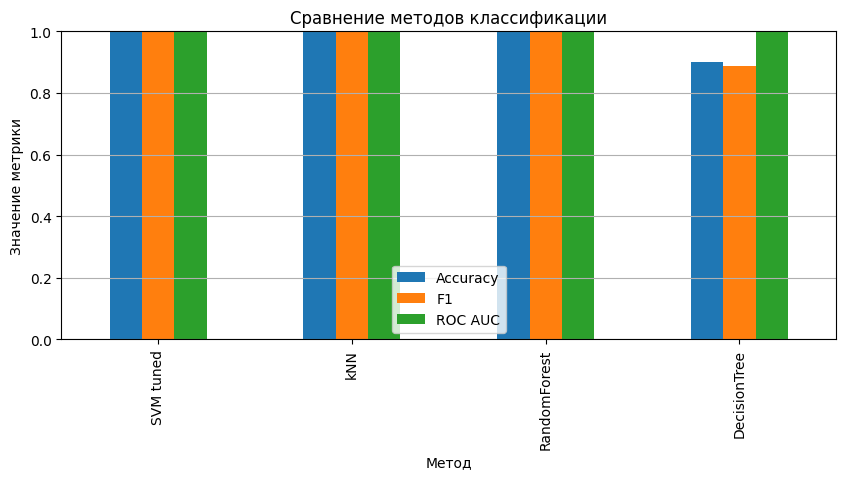

In [19]:
plt.figure(figsize=(10, 4))
metrics_to_plot = ['Accuracy', 'F1', 'ROC AUC']
comparison_df.set_index('Метод')[metrics_to_plot].plot(kind='bar', figsize=(10, 4))
plt.title('Сравнение методов классификации')
plt.ylim(0, 1)
plt.ylabel('Значение метрики')
plt.grid(axis='y')
plt.show()

## Дополнительное сравнение регрессии

На датасете гиперспектра сравним SVR с линейной регрессией, kNN-регрессией и случайным лесом.

In [20]:
regression_models = {
    'SVR tuned': best_svr,
    'LinearRegression': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'kNN Regressor': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=5))]),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
}

reg_rows = []
for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    pred = model.predict(X_test_reg)
    reg_rows.append({'Метод': name, **regression_metrics(y_test_reg, pred)})

reg_comparison_df = pd.DataFrame(reg_rows).sort_values('RMSE')
reg_comparison_df

,Метод,MAE,RMSE,R2
3,RandomForestRegressor,0.009024,0.013809,0.993529
2,kNN Regressor,0.011913,0.019203,0.987487
0,SVR tuned,0.027102,0.038521,0.949647
1,LinearRegression,0.092709,0.129167,0.433849


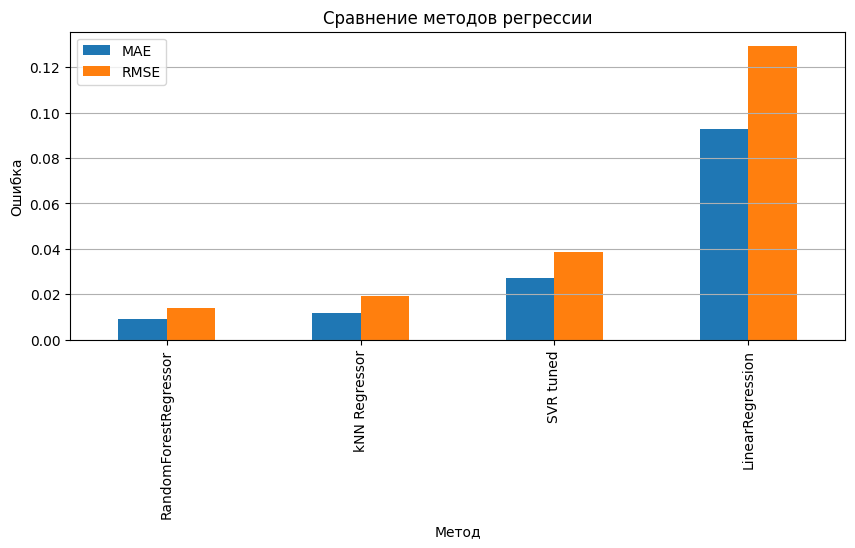

In [21]:
reg_comparison_df.set_index('Метод')[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 4))
plt.title('Сравнение методов регрессии')
plt.ylabel('Ошибка')
plt.grid(axis='y')
plt.show()

## Вывод

В практической работе был рассмотрен метод опорных векторов для классификации и регрессии.

В задаче классификации были проверены разные ядра `SVC`: линейное, полиномиальное, RBF и sigmoid. После подбора гиперпараметров через `GridSearchCV` была выбрана лучшая конфигурация по F1-мере. Визуализация границ решений показала, что разные ядра строят разные разделяющие поверхности.

В задаче регрессии на датасете гиперспектра кукурузы были сравнены разные ядра `SVR`, после чего гиперпараметры были подобраны по RMSE. Визуально видно, что нелинейные ядра лучше подходят для описания спектральной зависимости.

Дополнительно SVM был сравнен с методами из предыдущих практических работ: kNN, деревом решений, случайным лесом и линейной регрессией. Для классификации использовались метрики `Accuracy`, `Precision`, `Recall`, `F1`, `ROC AUC`; для регрессии — `MAE`, `RMSE`, `R2`.